# Joint imbalance experiment — in-memory matched-loss arrays

Joint training, data, and initialization conventions are unchanged. Positive QK imbalance is key-heavy in this notebook. Attention metrics are evaluated on the fixed test set; matching uses full training-set NLL at each frozen snapshot.

No plotting or CSV export. Checkpoint saving is disabled by default. The final cell returns `averages[(lambda_qk, lambda_ov)]`, with one array per metric in `loss_thresholds` order. Metrics are linearly interpolated at each seed's first downward loss crossing before averaging across seeds. These are estimates, not newly evaluated exact-loss models. Average training loss therefore equals the requested threshold up to numerical precision.

Attention entropy is provided in bits and normalized by log2(number of attended positions). Effective QK and OV norms are Frobenius norms of the effective products, not averages of the factor norms. Missing thresholds remain NaN unless every configured seed has a finite estimate for that metric; `n_seeds` and bracket widths remain available for inspection. Enable additional model seeds in `full_cfg` for a multi-seed average.


In [1]:
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)


Device: mps


In [3]:
def _balanced_singular_values(singular_values: np.ndarray,
                              lmda: float) -> Tuple[np.ndarray, np.ndarray]:
    """
       Numerically stable construction of a, b satisfying
                 a_i * b_i = s_i
                 a_i^2 - b_i^2 = lambda

       Here:
                 a belongs to W_K, WO
                 b belongs to W_Q, WV

       Therefore lambda > 0 is key-heavy under

                 W_K.T @ W_K - W_Q.T @ W_Q = lambda I.
    """
    s = np.asarray(singular_values, dtype=np.float64)

    # More stable than sqrt(lambda**2 + 4*s**2).
    root = np.hypot(float(lmda), 2.0 * s) # computes the hypotenuse

    if lmda >= 0:
        # This branch computes the large factor directly.
        a = np.sqrt(0.5 * (root + lmda))

        # Compute the small factor from ab=s, avoiding
        # root - lambda catastrophic cancellation.
        b = np.divide(s,a,
                      out=np.zeros_like(s),where=a > 0)

    else:
        # When lambda < 0, b is the large factor.
        b = np.sqrt(0.5 * (root - lmda))

        # Compute the small factor from ab=s.
        a = np.divide(s,b,
                      out=np.zeros_like(s),where=b > 0)

    return a, b

In [4]:
def get_lambda_balanced_query_key(lmda: float,d_model: int,
                                  d_head: int,sigma: float = 1.0,
                                  seed: int = 42,) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
       Construct PyTorch-compatible key/query weights preserving

                          C_QK = W_K W_Q^T

       and imposing

                          W_K^T W_K - W_Q^T W_Q = lambda I_{d_head}.

       The theoretical matrices have shape
                          W_K, W_Q: (d_model, d_head).

       PyTorch nn.Linear stores their transposes: key_weight, query_weight: (d_head, d_model).

       Positive lambda is key-heavy.
    """
    if d_head > d_model:
        raise ValueError("The construction requires d_head <= d_model.")

    rng = np.random.default_rng(seed)

    std = sigma * np.sqrt(2.0 / d_model)

    # Theoretical base matrices.
    W_K_base = rng.standard_normal((d_model, d_head)).astype(np.float64) * std

    W_Q_base = rng.standard_normal((d_model, d_head)).astype(np.float64) * std

    # Effective QK product to preserve.
    C0 = W_K_base @ W_Q_base.T

    U, S, Vt = np.linalg.svd(C0,full_matrices=False)

    # Internal orthogonal gauge.
    R_raw = rng.standard_normal((d_head, d_head)).astype(np.float64)

    R, _ = np.linalg.qr(R_raw)

    # Stable factor singular values:
    #
    # a_i b_i = S_i
    # a_i^2 - b_i^2 = lambda
    a, b = _balanced_singular_values(S[:d_head],lmda,)

    # W_K = U diag(a) R^T
    # W_Q = V diag(b) R^T
    W_K = (U[:, :d_head]@ np.diag(a)@ R.T)

    W_Q = (Vt.T[:, :d_head]@ np.diag(b)@ R.T)

    # PyTorch nn.Linear storage orientation.
    key_weight = W_K.T
    query_weight = W_Q.T

    return key_weight, query_weight, C0

In [5]:
wk, wq, c = get_lambda_balanced_query_key(0,50,50)
np.linalg.norm(wk@wk.T - wq@wq.T,ord="fro")

3.5812699045061484e-14

In [6]:
def get_lambda_balanced_output_value(lmda: float,d_model: int,
                                     d_value: int,d_out: int,sigma: float = 1.0,
                                     seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
       Construct W_O and W_V while preserving

                   C_OV = W_O W_V

       and imposing

                 W_O^T W_O - W_V W_V^T = lambda I_{d_value}.

       Shapes
       ------
      W_V: (d_value, d_model)

      W_O: (d_out, d_value)

      C_OV: (d_out, d_model)

      Sign convention
      ---------------
      lambda > 0: output-heavy

      lambda < 0:value-heavy

      Returns
      -------
      init_wo: Directly assignable to prediction_layer.weight.

      init_wv: Directly assignable to value_layer.weight.

      c0: Preserved effective OV product.
    """
    if d_value > min(d_model, d_out):
        raise ValueError("This construction requires " "d_value <= min(d_model, d_out).")

    rng = np.random.default_rng(seed)

    std_v = sigma * np.sqrt(2.0 / d_model)
    std_o = sigma * np.sqrt(2.0 / d_value)

    # These shapes are already PyTorch nn.Linear storage shapes.
    wv_base = (rng.standard_normal((d_value, d_model)).astype(np.float64)* std_v)

    wo_base = (
        rng.standard_normal((d_out, d_value))
        .astype(np.float64)
        * std_o
    )

    # Effective product to preserve.
    c0 = wo_base @ wv_base

    U, S, Vt = np.linalg.svd(c0,full_matrices=False,)

    R_raw = rng.standard_normal((d_value, d_value)).astype(np.float64)

    R, _ = np.linalg.qr(R_raw)

    # a belongs to W_O and b belongs to W_V:
    #
    # a_i b_i = S_i
    # a_i^2 - b_i^2 = lambda
    a, b = _balanced_singular_values(S[:d_value],lmda)

    # W_O = U diag(a) R^T
    init_wo = (U[:, :d_value]@ np.diag(a)@ R.T)

    # W_V = R diag(b) V^T
    init_wv = (R@ np.diag(b)@ Vt[:d_value, :])

    return init_wo, init_wv, c0

In [7]:
wo, wv, wov = get_lambda_balanced_output_value(100,50,50,100)
# Residual from the requested imbalance, not the size of the imbalance itself.
np.linalg.norm(wo.T @ wo - wv @ wv.T - 100 * np.eye(50), ord="fro")


1.2964094238558573e-12

In [8]:
class Net_p1(nn.Module):
    """
        Single-head self-attention model with lambda-balanced
        QK and OV initialization.

        QK convention
        -------------
        The theoretical matrices are W_K, W_Q in R^{d_model x d_head} and the effective QK circuit is

                                     C_QK = W_K W_Q^T.

        PyTorch stores key_layer.weight   = W_K^T query_layer.weight = W_Q^T.

        Therefore, using stored tensors,

                                     C_QK = K_store^T Q_store
        and the balancedness invariant is

                    Delta_QK = W_K^T W_K - W_Q^T W_Q = K_store K_store^T - Q_store Q_store^T.

        OV convention
        -------------
        PyTorch directly stores value_layer.weight      = W_V prediction_layer.weight = W_O.

        Therefore,

                    C_OV = W_O W_V and  Delta_OV = W_O^T W_O - W_V W_V^T.
    """

    def __init__( self, lmda_qk: float,lmda_ov: float, seed: int,
                 d_model: int = 50,d_head: int = 50,
                 d_value: int = 50,d_out: int = 50,
                 sigma_qk: float = 1.0,sigma_ov: float = 1.0):
        super().__init__()

        self.d_model = d_model
        self.d_head = d_head
        self.d_value = d_value
        self.d_out = d_out

        self.lmda_qk = float(lmda_qk)
        self.lmda_ov = float(lmda_ov)

        # ---------------------------------------------------------
        # Layers
        # ---------------------------------------------------------

        self.key_layer = nn.Linear(d_model,d_head,bias=False)

        self.query_layer = nn.Linear(d_model,d_head,bias=False)

        self.value_layer = nn.Linear(d_model,d_value,bias=False)

        self.prediction_layer = nn.Linear(d_value,d_out,bias=False)

        # ---------------------------------------------------------
        # Construct balanced QK factors
        # ---------------------------------------------------------

        init_wk, init_wq, target_qk_product = get_lambda_balanced_query_key(lmda=lmda_qk,d_model=d_model,
                                                                             d_head=d_head,sigma=sigma_qk,
                                                                             seed=seed)

        # Expected shapes: init_wk: (d_head, d_model) init_wq: (d_head, d_model)
        assert init_wk.shape == (d_head,d_model)

        assert init_wq.shape == (d_head,d_model)

        # ---------------------------------------------------------
        # Construct balanced OV factors
        # ---------------------------------------------------------

        init_wo, init_wv, target_ov_product = get_lambda_balanced_output_value(lmda=lmda_ov,d_model=d_model,
                                                                               d_value=d_value,d_out=d_out,
                                                                               sigma=sigma_ov,seed=seed)
    

        # Expected shapes: init_wo: (d_out, d_value) init_wv: (d_value, d_model)
        assert init_wo.shape == (d_out,d_value)

        assert init_wv.shape == (d_value,d_model)

        # Keep the seed-specific target products for the initialization audit.
        self._target_qk_product = target_qk_product
        self._target_ov_product = target_ov_product

        # ---------------------------------------------------------
        # Copy arrays into the existing Parameters
        # ---------------------------------------------------------

        with torch.no_grad():
            self.key_layer.weight.copy_(torch.as_tensor(init_wk,
                                                        dtype=self.key_layer.weight.dtype,
                                                        device=self.key_layer.weight.device))

            self.query_layer.weight.copy_(torch.as_tensor(init_wq,
                                                          dtype=self.query_layer.weight.dtype,
                                                          device=self.query_layer.weight.device))

            self.value_layer.weight.copy_(torch.as_tensor(init_wv,
                                                          dtype=self.value_layer.weight.dtype,
                                                          device=self.value_layer.weight.device))

            self.prediction_layer.weight.copy_(torch.as_tensor(init_wo,
                                                               dtype=self.prediction_layer.weight.dtype,
                                                               device=self.prediction_layer.weight.device))

    @torch.no_grad()
    def circuit_metrics(self):
        # Audit small matrices in CPU float64; MPS does not support float64.
        k, q, v, o = [layer.weight.detach().cpu().double().numpy()
                      for layer in (self.key_layer, self.query_layer,
                                    self.value_layer, self.prediction_layer)]
        dq = k @ k.T - q @ q.T  # Notebook convention: positive = key-heavy.
        dv = o.T @ o - v @ v.T
        q_target = self.lmda_qk * np.eye(self.d_head)
        v_target = self.lmda_ov * np.eye(self.d_value)
        return {
            "qk_product_norm": float(np.linalg.norm(k.T @ q)),
            "ov_product_norm": float(np.linalg.norm(o @ v)),
            "qk_imbalance_error": float(np.linalg.norm(dq - q_target)),
            "ov_imbalance_error": float(np.linalg.norm(dv - v_target)),
            "qk_imbalance_relative_error": float(
                np.linalg.norm(dq - q_target) / max(1.0, np.linalg.norm(q_target))),
            "ov_imbalance_relative_error": float(
                np.linalg.norm(dv - v_target) / max(1.0, np.linalg.norm(v_target))),
        }

    @torch.no_grad()
    def verify_initialization(self, tolerance=5e-5):
        k, q, v, o = [layer.weight.detach().cpu().double().numpy()
                      for layer in (self.key_layer, self.query_layer,
                                    self.value_layer, self.prediction_layer)]
        metrics = self.circuit_metrics()
        for name, actual, target in (
            ("qk", k.T @ q, self._target_qk_product),
            ("ov", o @ v, self._target_ov_product),
        ):
            metrics[name + "_product_relative_error"] = float(
                np.linalg.norm(actual - target) / max(1.0, np.linalg.norm(target)))
        errors = [value for name, value in metrics.items()
                  if name.endswith("relative_error")]
        if not all(np.isfinite(value) and value <= tolerance for value in errors):
            raise ValueError(f"Initialization audit failed: {metrics}")
        #print(metrics)
        return metrics

    # =============================================================
    # Forward
    # =============================================================

    def forward(self, x):
        """
        x: (batch, sequence_length, d_model)
        """

        batch, seq_len, vocab_size = x.shape

        # key_i = x_i W_K
        key = self.key_layer(x)

        # query = x_last W_Q
        query = self.query_layer(x[:, -1, :]).unsqueeze(1)

        # This computes (x_query W_Q)(x_i W_K)^T which is a scalar equal to x_i W_K W_Q^T x_query^T.
        scores = ( query @ key.k 

        attn = torch.softmax(scores, dim=-1)

        values = self.value_layer(x)

        context = torch.matmul(attn,values)

        output = self.prediction_layer(context)

        return output[:, 0, :], attn[:, 0, :]


In [9]:
def set_all_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [10]:
@dataclass
class ExperimentConfig:
    # Data
    seq_len: int = 256
    vocab_size: int = 50

    # Number of examples per class.
    # Labels are assumed to be 1, 2, 3, 4.
    n_train_per_class: int = 400
    n_test_per_class: int = 512

    generation_batch_size: int = 256
    train_batch_size: int = 32
    eval_batch_size: int = 256

    # Training
    n_epochs: int = 1200
    learning_rate: float = 1e-2
    momentum: float = 0.0
    weight_decay: float = 0.0

    record_every_epochs: int = 1
    loss_thresholds: Tuple[float, ...] = (1.2, 1.0, 0.8, 0.4, 0.2, 0.1, 0.08, 0.05, 0.01, 0.005)

    # Initialization
    sigma_qk: float = 1.0
    sigma_ov: float = 1.0

    # Grid
    lambda_qk_values: Tuple[float, ...] = (0, 10, 200)

    lambda_ov_values: Tuple[float, ...] = (0, 10, 200)

    model_seeds: Tuple[int, ...] = (1234,)

    # A single fixed train/test dataset is reused by all runs.
    train_dataset_seed: int = 73001
    test_dataset_seed: int = 83001

    # Minibatch order changes across model seeds, but is identical
    # across lambda pairs for the same seed.
    shuffle_seed_offset: int = 93001



    save_checkpoints: bool = False

In [11]:
seq_class = []
total_tokens = 50
offset = 10

for i in range(4):
    temp = np.zeros(total_tokens)
    temp[:offset] = 1
    temp[(i+1)*offset:((i+2)*offset)] = np.arange(0.1,1.1,0.1)
    temp = temp/sum(temp)
    seq_class.append(temp)
    assert np.isclose(seq_class[i].sum(), 1.0)

def sample_sequence(next_token,seq_len):
    '''
    function to sample a sequence based on p(l|m,n) for given m and n.
    '''
    query_tokens = [5,6,7,8]
    next_tokens = [1,2,3,4]
    if next_token==next_tokens[0]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[0],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[0],next_token])
    if next_token==next_tokens[1]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[1],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[1],next_token])
    if next_token==next_tokens[2]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[2],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[2],next_token])
    if next_token==next_tokens[3]:
        context_tokens = np.random.choice(np.arange(50),p=seq_class[3],size=seq_len-2)
        seq = np.append(context_tokens,[query_tokens[3],next_token])
    return seq

def generate_data(batch_size,seq_len):
    batch_of_seq = []
    next_tokens = [1,2,3,4]
    for i in range(batch_size):
        next_token = np.random.choice(next_tokens,p=[0.25]*4)
        generated_seq = sample_sequence(next_token,seq_len)
        batch_of_seq.append(torch.tensor(generated_seq))
    return torch.vstack(batch_of_seq)


def analyse_model(model,batch_size,seq_len):
    test_inputs = generate_data(batch_size,seq_len)
    tinputs,tlabels  = test_inputs[:,:-1].to(device),test_inputs[:,-1].to(device)

    model.eval()
    with torch.no_grad():
        model_output,model_attention = model(
            F.one_hot(tinputs.long(), num_classes=model.d_model).float())
    #model_output = nn.Softmax(dim=1)(model_output)

    common_tokens_attn = []
    distinct_tokens_attn = []
    for i in range(batch_size):
        indices_1 = torch.logical_and(tinputs[i]>=0,tinputs[i]<10)
        indices_2 = torch.logical_and(tinputs[i] >= 10 * tlabels[i],
                                      tinputs[i] < 10 * (tlabels[i] + 1))
        indices_1[-1] = False  # Query position is not common CONTEXT.
        indices_2[-1] = False
        common_tokens_attn.append(sum(model_attention[i][indices_1]).item())
        distinct_tokens_attn.append(sum(model_attention[i][indices_2]).item())
    return np.mean(common_tokens_attn),np.mean(distinct_tokens_attn)



In [12]:
def make_fixed_balanced_dataset(
    generate_data_fn,
    n_per_class: int,
    seq_len: int,
    generation_batch_size: int,
    seed: int,
    class_labels: Sequence[int] = (1, 2, 3, 4),
    max_batches: int = 100000,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Construct a fixed balanced dataset from the existing generate_data
    function.

    Assumes generate_data_fn(batch_size, seq_len) returns a tensor whose:
        data[:, :-1] = model input token IDs
        data[:, -1]  = target labels
    """
    set_all_seeds(seed)

    class_labels = tuple(int(label) for label in class_labels)

    token_buckets = {
        label: []
        for label in class_labels
    }

    counts = {
        label: 0
        for label in class_labels
    }

    n_batches_generated = 0

    while min(counts.values()) < n_per_class:
        if n_batches_generated >= max_batches:
            raise RuntimeError(
                "Could not collect enough examples for every class. "
                f"Current counts: {counts}"
            )

        data = generate_data_fn(
            generation_batch_size,
            seq_len,
        )

        if not torch.is_tensor(data):
            data = torch.as_tensor(data)

        data = data.detach().cpu().long()

        input_tokens = data[:, :-1]
        labels = data[:, -1]

        for label in class_labels:
            remaining = n_per_class - counts[label]

            if remaining <= 0:
                continue

            matching = torch.where(
                labels == label
            )[0]

            if matching.numel() == 0:
                continue

            matching = matching[:remaining]

            token_buckets[label].append(
                input_tokens.index_select(
                    0,
                    matching,
                )
            )

            counts[label] += int(
                matching.numel()
            )

        n_batches_generated += 1

    all_tokens = []
    all_labels = []

    for label in class_labels:
        class_tokens = torch.cat(
            token_buckets[label],
            dim=0,
        )[:n_per_class]

        class_labels_tensor = torch.full(
            (n_per_class,),
            fill_value=label,
            dtype=torch.long,
        )

        all_tokens.append(class_tokens)
        all_labels.append(class_labels_tensor)

    tokens = torch.cat(
        all_tokens,
        dim=0,
    )

    labels = torch.cat(
        all_labels,
        dim=0,
    )

    # Deterministic final dataset shuffle
    generator = torch.Generator()
    generator.manual_seed(seed + 1)

    permutation = torch.randperm(
        tokens.shape[0],
        generator=generator,
    )

    tokens = tokens.index_select(
        0,
        permutation,
    )

    labels = labels.index_select(
        0,
        permutation,
    )

    #print("Dataset shape:", tokens.shape)
    #print(
        "Class counts:",
        {
            label: int((labels == label).sum())
            for label in class_labels
        },
    )

    return tokens, labels

In [13]:
cfg = ExperimentConfig()

train_tokens, train_labels = make_fixed_balanced_dataset(
    generate_data_fn=generate_data,
    n_per_class=cfg.n_train_per_class,
    seq_len=cfg.seq_len,
    generation_batch_size=cfg.generation_batch_size,
    seed=cfg.train_dataset_seed,
)

test_tokens, test_labels = make_fixed_balanced_dataset(
    generate_data_fn=generate_data,
    n_per_class=cfg.n_test_per_class,
    seq_len=cfg.seq_len,
    generation_batch_size=cfg.generation_batch_size,
    seed=cfg.test_dataset_seed,
)

Dataset shape: torch.Size([1600, 255])
Class counts: {1: 400, 2: 400, 3: 400, 4: 400}
Dataset shape: torch.Size([2048, 255])
Class counts: {1: 512, 2: 512, 3: 512, 4: 512}


In [14]:
def iterate_fixed_batches(
    tokens: torch.Tensor,
    labels: torch.Tensor,
    batch_size: int,
    permutation: np.ndarray,
):
    """
    Yield minibatches according to a supplied permutation.
    """
    n_examples = int(tokens.shape[0])

    for start in range(
        0,
        n_examples,
        batch_size,
    ):
        batch_indices_np = permutation[
            start:start + batch_size
        ]

        batch_indices = torch.from_numpy(
            np.asarray(
                batch_indices_np,
                dtype=np.int64,
            )
        )

        yield (
            tokens.index_select(
                0,
                batch_indices,
            ),
            labels.index_select(
                0,
                batch_indices,
            ),
        )

In [15]:
def train_one_model(
    model: Net_p1,
    train_tokens: torch.Tensor,
    train_labels: torch.Tensor,
    device: torch.device,
    n_epochs: int,
    batch_size: int,
    learning_rate: float,
    momentum: float,
    weight_decay: float,
    record_every_epochs: int,
    shuffle_seed: int,
    lambda_qk: float,
    lambda_ov: float,
    model_seed: int,
    test_tokens: torch.Tensor,
    test_labels: torch.Tensor,
    eval_batch_size: int = 256,
    vocab_size: int = 50,
    loss_thresholds: Sequence[float] = (0.1, 0.01, 0.001),
    checkpoint_dir: Optional[Path] = None,
) -> Tuple[pd.DataFrame, List[float]]:
    if n_epochs < 1 or record_every_epochs < 1:
        raise ValueError("n_epochs and record_every_epochs must be positive.")
    if any(not np.isfinite(t) or t <= 0 for t in loss_thresholds):
        raise ValueError("Loss thresholds must be finite and positive.")
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay,
    )

    shuffle_rng = np.random.default_rng(
        shuffle_seed
    )

    trajectory_rows = []
    epoch_losses = []

    optimization_step = 0

    pending_thresholds = set(float(t) for t in loss_thresholds)
    previous_row = None
    previous_state = None

    def record_state(epoch, mean_batch_loss=np.nan):
        nonlocal previous_row, previous_state
        # Both losses are measured at this ONE frozen model state.
        train_evaluation = evaluate_model(
            model, train_tokens, train_labels, device, eval_batch_size, vocab_size)
        evaluation = evaluate_model(
            model, test_tokens, test_labels, device, eval_batch_size, vocab_size)
        row = {
            "model_seed": model_seed,
            "lambda_qk": float(lambda_qk),
            "lambda_ov": float(lambda_ov),
            "epoch": epoch,
            "optimization_step": optimization_step,
            "train_loss": train_evaluation["test_loss"],
            "mean_batch_train_loss": mean_batch_loss,
            **model.circuit_metrics(),
            **{key: value for key, value in evaluation.items() if np.isscalar(value)},
        }
        if not np.isfinite(row["train_loss"]):
            raise FloatingPointError("Non-finite snapshot training loss.")
        trajectory_rows.append(row)

        if checkpoint_dir is not None and pending_thresholds:
            checkpoint_dir.mkdir(parents=True, exist_ok=True)
            state = {key: value.detach().cpu().clone()
                     for key, value in model.state_dict().items()}
            for target in sorted(pending_thresholds, reverse=True):
                above = previous_row if previous_row is not None else row
                if above["train_loss"] >= target >= row["train_loss"]:
                    above_state = previous_state if previous_state is not None else state
                    for side, saved_row, saved_state in (
                        ("above", above, above_state), ("below", row, state)
                    ):
                        name = (f"model_seed{model_seed}_qk{lambda_tag(lambda_qk)}"
                                f"_ov{lambda_tag(lambda_ov)}_loss{lambda_tag(target)}_{side}.pt")
                        torch.save({"model_state_dict": saved_state,
                                    "target_train_loss": target,
                                    "metrics": saved_row}, checkpoint_dir / name)
                    pending_thresholds.remove(target)
            if previous_row is None:
                # No crossing is observed for targets already above initial loss.
                pending_thresholds.difference_update(
                    t for t in list(pending_thresholds) if t > row["train_loss"])
            previous_state = state
        previous_row = row

    record_state(0)

    n_train = int(train_tokens.shape[0])

    progress = tqdm(
        range(1, n_epochs + 1),
        desc=(
            f"QK={lambda_qk:g}, "
            f"OV={lambda_ov:g}, "
            f"seed={model_seed}"
        ),
        leave=False,
    )

    for epoch in progress:
        model.train()

        # Using the same shuffle_seed for a particular model seed
        # guarantees identical minibatches across lambda pairs.
        permutation = shuffle_rng.permutation(
            n_train
        )

        total_loss = 0.0
        total_examples = 0

        for token_batch_cpu, label_batch_cpu in iterate_fixed_batches(
            tokens=train_tokens,
            labels=train_labels,
            batch_size=batch_size,
            permutation=permutation,
        ):
            token_batch = token_batch_cpu.to(
                device
            )

            label_batch = label_batch_cpu.to(
                device
            )

            input_batch = F.one_hot(
                token_batch,
                num_classes=vocab_size,
            ).float()

            optimizer.zero_grad()

            logits, _ = model(input_batch)

            loss = criterion(
                logits,
                label_batch,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at epoch {epoch}.")

            loss.backward()
            optimizer.step()

            actual_batch_size = int(
                label_batch.shape[0]
            )

            total_loss += (
                float(loss.item())
                * actual_batch_size
            )

            total_examples += (
                actual_batch_size
            )

            optimization_step += 1

        mean_epoch_loss = (
            total_loss
            / max(total_examples, 1)
        )

        epoch_losses.append(
            mean_epoch_loss
        )

        progress.set_postfix(
            loss=f"{mean_epoch_loss:.5f}"
        )

        if (
            epoch % record_every_epochs == 0
            or epoch == n_epochs
        ):

            record_state(epoch, mean_epoch_loss)

    return (
        pd.DataFrame(trajectory_rows),
        epoch_losses,
    )


In [16]:
@torch.no_grad()
def evaluate_model(
    model: Net_p1,
    test_tokens: torch.Tensor,
    test_labels: torch.Tensor,
    device: torch.device,
    eval_batch_size: int,
    vocab_size: int = 50,
) -> Dict[str, object]:
    model.eval()

    all_distinct_mass = []
    all_correct_probability = []
    all_entropy_bits = []
    all_entropy_normalized = []
    all_uniform_distinct_mass = []
    all_common_mass = []
    all_query_mass = []

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    n_test = int(test_tokens.shape[0])

    for start in range(
        0,
        n_test,
        eval_batch_size,
    ):
        token_batch = test_tokens[
            start:start + eval_batch_size
        ].to(device)

        label_batch = test_labels[
            start:start + eval_batch_size
        ].to(device)

        inputs = F.one_hot(
            token_batch,
            num_classes=vocab_size,
        ).float()

        logits, attention = model(inputs)

        probabilities = torch.softmax(
            logits,
            dim=-1,
        )

        batch_size_actual = int(
            label_batch.shape[0]
        )

        row_indices = torch.arange(
            batch_size_actual,
            device=device,
        )

        correct_probability = probabilities[
            row_indices,
            label_batch,
        ]

        predicted_labels = logits.argmax(
            dim=-1
        )

        # True-class distinct CONTEXT tokens: class c uses IDs 10*c,...,10*c+9.
        distinct_mask = ((token_batch >= 10 * label_batch[:, None])
                         & (token_batch < 10 * (label_batch[:, None] + 1)))
        distinct_mask[:, -1] = False
        common_mask = (token_batch >= 0) & (token_batch < 10)
        common_mask[:, -1] = False  # Query is a separate position/category.
        common_mass = (attention * common_mask.float()).sum(dim=-1)
        query_mass = attention[:, -1]

        distinct_attention_mass = (
            attention
            * distinct_mask.float()
        ).sum(dim=-1)

        # Expected distinct mass under uniform attention.
        uniform_distinct_mass = (
            distinct_mask.float().mean(dim=-1)
        )

        attention_safe = attention.clamp_min(
            1e-12
        )

        entropy_bits = -(
            attention
            * torch.log2(attention_safe)
        ).sum(dim=-1)

        maximum_entropy = math.log2(
            attention.shape[-1]
        )

        entropy_normalized = (
            entropy_bits
            / maximum_entropy
        )

        total_loss += float(
            F.cross_entropy(
                logits,
                label_batch,
                reduction="sum",
            ).item()
        )

        total_correct += int(
            (
                predicted_labels
                == label_batch
            ).sum().item()
        )

        total_examples += batch_size_actual

        all_distinct_mass.append(
            distinct_attention_mass.cpu().numpy()
        )
        all_common_mass.append(common_mass.cpu().numpy())
        all_query_mass.append(query_mass.cpu().numpy())

        all_correct_probability.append(
            correct_probability.cpu().numpy()
        )

        all_entropy_bits.append(
            entropy_bits.cpu().numpy()
        )

        all_entropy_normalized.append(
            entropy_normalized.cpu().numpy()
        )

        all_uniform_distinct_mass.append(
            uniform_distinct_mass.cpu().numpy()
        )

    distinct_mass = np.concatenate(
        all_distinct_mass
    )

    correct_probability = np.concatenate(
        all_correct_probability
    )
    common_mass = np.concatenate(all_common_mass)
    query_mass = np.concatenate(all_query_mass)

    entropy_bits = np.concatenate(
        all_entropy_bits
    )

    entropy_normalized = np.concatenate(
        all_entropy_normalized
    )

    uniform_distinct_mass = np.concatenate(
        all_uniform_distinct_mass
    )

    return {
        "test_loss":
            total_loss / total_examples,

        "test_accuracy":
            total_correct / total_examples,

        "correct_probability_mean":
            float(correct_probability.mean()),

        "correct_probability_std":
            float(correct_probability.std()),

        "distinct_mass_mean":
            float(distinct_mass.mean()),

        "distinct_mass_std":
            float(distinct_mass.std()),

        "common_context_mass_mean": float(common_mass.mean()),
        "query_mass_mean": float(query_mass.mean()),

        "uniform_distinct_mass_mean":
            float(uniform_distinct_mass.mean()),

        "distinct_mass_excess_mean":
            float(
                (
                    distinct_mass
                    - uniform_distinct_mass
                ).mean()
            ),

        "entropy_bits_mean":
            float(entropy_bits.mean()),

        "entropy_bits_std":
            float(entropy_bits.std()),

        "entropy_normalized_mean":
            float(entropy_normalized.mean()),

        "entropy_normalized_std":
            float(entropy_normalized.std()),

        # Raw arrays for per-run distribution heatmaps
        "distinct_mass_values":
            distinct_mass,

        "common_context_mass_values": common_mass,
        "query_mass_values": query_mass,

        "correct_probability_values":
            correct_probability,

        "entropy_bits_values":
            entropy_bits,

        "entropy_normalized_values":
            entropy_normalized,
    }


In [17]:
def lambda_tag(value):
    return f"{float(value):g}".replace("-", "m").replace(".", "p")


def summarize_matched_losses(trajectory_df, loss_thresholds):
    """Interpolate metrics at the FIRST recorded downward loss crossing.

    These are explicitly labeled estimates, not evaluations of an invented
    exact-loss model. Keep both observed losses and the relative bracket width.
    Never extrapolate a target that is not bracketed by recorded snapshots.
    """
    metrics = ["train_loss", "qk_product_norm", "ov_product_norm", "test_loss", "test_accuracy", "correct_probability_mean",
               "distinct_mass_mean", "common_context_mass_mean", "query_mass_mean",
               "entropy_bits_mean", "entropy_normalized_mean"]
    rows = []
    keys = ["model_seed", "lambda_qk", "lambda_ov"]
    for values, group in trajectory_df.groupby(keys):
        group = group.sort_values("epoch").reset_index(drop=True)
        losses = group["train_loss"].to_numpy(dtype=float)
        if not np.all(np.isfinite(losses)):
            raise ValueError("Matched-loss analysis needs finite snapshot losses.")
        for target in loss_thresholds:
            row = {**dict(zip(keys, values)), "target_train_loss": float(target),
                   "status": "not_reached",
                   "train_loss_above": np.nan, "train_loss_below": np.nan,
                   "epoch_above": np.nan, "epoch_below": np.nan,
                   "loss_bracket_relative_width": np.nan,
                   **{"estimated_" + metric: np.nan for metric in metrics}}
            if losses[0] < target:
                row["status"] = "below_target_at_initialization"
                rows.append(row)
                continue
            if losses[0] == target:
                lo = hi = group.iloc[0]
            else:
                crossings = np.flatnonzero((losses[:-1] >= target)
                                          & (losses[1:] <= target))
                if not len(crossings):
                    rows.append(row)
                    continue
                index = int(crossings[0])
                lo, hi = group.iloc[index], group.iloc[index + 1]
            above, below = float(lo["train_loss"]), float(hi["train_loss"])
            fraction = 0.0 if above == below else (above - target) / (above - below)
            row.update(status="exact" if fraction in (0.0, 1.0) else "interpolated",
                       train_loss_above=above, train_loss_below=below,
                       epoch_above=int(lo["epoch"]), epoch_below=int(hi["epoch"]),
                       loss_bracket_relative_width=(above - below) / target)
            for metric in metrics:
                row["estimated_" + metric] = float(
                    (1.0 - fraction) * lo[metric] + fraction * hi[metric])
            rows.append(row)
    return pd.DataFrame(rows)


In [18]:
def run_lambda_grid(
    cfg: ExperimentConfig,
    train_tokens: torch.Tensor,
    train_labels: torch.Tensor,
    test_tokens: torch.Tensor,
    test_labels: torch.Tensor,
    device: torch.device,
):
    # The existing generator has four classes and seq_len includes the target.
    for tokens, labels, n_per_class in (
        (train_tokens, train_labels, cfg.n_train_per_class),
        (test_tokens, test_labels, cfg.n_test_per_class),
    ):
        if tokens.shape != (4 * n_per_class, cfg.seq_len - 1):
            raise ValueError("Dataset shape differs from cfg; regenerate the fixed datasets.")
        if any(int((labels == c).sum()) != n_per_class for c in (1, 2, 3, 4)):
            raise ValueError("Dataset class counts differ from cfg.")
    if cfg.vocab_size != 50:
        raise ValueError("The unchanged data generator uses a 50-token vocabulary.")
    output_dir = Path("./")

    checkpoint_dir = (
        output_dir / "checkpoints"
    )





    all_final_rows = []
    all_trajectory_frames = []

    total_pairs = (
        len(cfg.lambda_qk_values)
        * len(cfg.lambda_ov_values)
    )

    pair_index = 0

    for lambda_qk in cfg.lambda_qk_values:
        for lambda_ov in cfg.lambda_ov_values:
            pair_index += 1

            # print(
            #     "\n"
            #     f"[{pair_index}/{total_pairs}] "
            #     f"lambda_QK={lambda_qk}, "
            #     f"lambda_OV={lambda_ov}"
            # )

            pair_final_rows = []
            pair_trajectory_frames = []

            for model_seed in cfg.model_seeds:
                set_all_seeds(model_seed)

                model = Net_p1(
                    lmda_qk=lambda_qk,
                    lmda_ov=lambda_ov,
                    seed=model_seed,
                    d_model=50,
                    d_head=50,
                    d_value=50,
                    d_out=50,
                    sigma_qk=cfg.sigma_qk,
                    sigma_ov=cfg.sigma_ov,
                ).float().to(device)

                # print(
                #     f"Initialization check, "
                #     f"seed={model_seed}"
                # )

                initialization_metrics = (
                    model.verify_initialization()
                )

                trajectory_df, epoch_losses = (
                    train_one_model(
                        model=model,
                        train_tokens=train_tokens,
                        train_labels=train_labels,
                        device=device,
                        n_epochs=cfg.n_epochs,
                        batch_size=(
                            cfg.train_batch_size
                        ),
                        learning_rate=(
                            cfg.learning_rate
                        ),
                        momentum=cfg.momentum,
                        weight_decay=(
                            cfg.weight_decay
                        ),
                        record_every_epochs=(
                            cfg.record_every_epochs
                        ),
                        shuffle_seed=(
                            cfg.shuffle_seed_offset
                            + model_seed
                        ),
                        lambda_qk=lambda_qk,
                        lambda_ov=lambda_ov,
                        model_seed=model_seed,
                        test_tokens=test_tokens,
                        test_labels=test_labels,
                        eval_batch_size=cfg.eval_batch_size,
                        vocab_size=cfg.vocab_size,
                        loss_thresholds=cfg.loss_thresholds,
                        checkpoint_dir=checkpoint_dir if cfg.save_checkpoints else None,
                    )
                )

                evaluation = evaluate_model(
                    model=model,
                    test_tokens=test_tokens,
                    test_labels=test_labels,
                    device=device,
                    eval_batch_size=(
                        cfg.eval_batch_size
                    ),
                    vocab_size=50,
                )



                final_row = {
                    "model_seed":
                        model_seed,

                    "lambda_qk":
                        float(lambda_qk),

                    "lambda_ov":
                        float(lambda_ov),

                    "final_train_loss":
                        float(
                            trajectory_df.iloc[-1]["train_loss"]
                        ),

                    "test_loss":
                        evaluation["test_loss"],

                    "test_accuracy":
                        evaluation[
                            "test_accuracy"
                        ],

                    "correct_probability_mean":
                        evaluation[
                            "correct_probability_mean"
                        ],

                    "distinct_mass_mean":
                        evaluation[
                            "distinct_mass_mean"
                        ],

                    "uniform_distinct_mass_mean":
                        evaluation[
                            "uniform_distinct_mass_mean"
                        ],

                    "distinct_mass_excess_mean":
                        evaluation[
                            "distinct_mass_excess_mean"
                        ],

                    "entropy_bits_mean":
                        evaluation[
                            "entropy_bits_mean"
                        ],

                    "entropy_normalized_mean":
                        evaluation[
                            "entropy_normalized_mean"
                        ],

                    "common_context_mass_mean": evaluation["common_context_mass_mean"],
                    "query_mass_mean": evaluation["query_mass_mean"],
                    **{"init_" + key: value for key, value in initialization_metrics.items()},

                }

                pair_final_rows.append(
                    final_row
                )

                all_final_rows.append(
                    final_row
                )

                pair_trajectory_frames.append(
                    trajectory_df
                )

                all_trajectory_frames.append(
                    trajectory_df
                )



                if cfg.save_checkpoints:
                    checkpoint_name = (
                        f"model_seed{model_seed}"
                        f"_qk{lambda_tag(lambda_qk)}"
                        f"_ov{lambda_tag(lambda_ov)}"
                        ".pt"
                    )

                    torch.save(
                        {
                            "model_state_dict":
                                model.state_dict(),

                            "model_seed":
                                model_seed,

                            "lambda_qk":
                                float(lambda_qk),

                            "lambda_ov":
                                float(lambda_ov),

                            "config":
                                cfg.__dict__,
                        },
                        checkpoint_dir
                        / checkpoint_name,
                    )

                del model

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            pair_final_df = pd.DataFrame(
                pair_final_rows
            )












    final_per_seed_df = pd.DataFrame(
        all_final_rows
    )

    trajectory_df = pd.concat(
        all_trajectory_frames,
        ignore_index=True,
    )

    metrics_to_aggregate = [
        "final_train_loss",
        "test_loss",
        "test_accuracy",
        "correct_probability_mean",
        "distinct_mass_mean",
        "uniform_distinct_mass_mean",
        "distinct_mass_excess_mean",
        "entropy_bits_mean",
        "entropy_normalized_mean",
        "common_context_mass_mean",
        "query_mass_mean",
    ]

    aggregate_rows = []

    for (
        lambda_qk,
        lambda_ov,
    ), group in final_per_seed_df.groupby(
        ["lambda_qk", "lambda_ov"]
    ):
        row = {
            "lambda_qk":
                float(lambda_qk),

            "lambda_ov":
                float(lambda_ov),
        }

        for metric in metrics_to_aggregate:
            row[metric] = float(
                group[metric].mean()
            )

            row[metric + "_std"] = float(
                group[metric].std(ddof=0)
            )

        aggregate_rows.append(row)

    aggregate_df = pd.DataFrame(
        aggregate_rows
    )





    return (
        final_per_seed_df,
        aggregate_df,
        trajectory_df,
    )


In [19]:
full_cfg = ExperimentConfig(
    lambda_qk_values=(0, 40, 200),

    lambda_ov_values=(
        0, 10,40, 200,
    ),

    model_seeds=(
        1234,
        1235,
        1236,
        1237,
        1238,
    ),

    seq_len=256,

    n_train_per_class=400,
    n_test_per_class=512,

    train_batch_size=32,
    eval_batch_size=256,

    n_epochs=1200,
    record_every_epochs=1,

    learning_rate=1e-2,

    sigma_qk=1.0,
    sigma_ov=1.0,

)

In [20]:
final_per_seed_df, aggregate_df, trajectory_df = (
    run_lambda_grid(
        cfg=full_cfg,
        train_tokens=train_tokens,
        train_labels=train_labels,
        test_tokens=test_tokens,
        test_labels=test_labels,
        device=device,
    )
)


[1/12] lambda_QK=0, lambda_OV=0
Initialization check, seed=1234
{'qk_product_norm': 14.33470648405718, 'ov_product_norm': 14.228668004141314, 'qk_imbalance_error': 5.76697277098716e-07, 'ov_imbalance_error': 5.774861822403604e-07, 'qk_imbalance_relative_error': 5.76697277098716e-07, 'ov_imbalance_relative_error': 5.774861822403604e-07, 'qk_product_relative_error': 2.7229020322697585e-08, 'ov_product_relative_error': 2.6941296966150858e-08}


QK=0, OV=0, seed=1234:   0%|          | 0/1200 [00:00<?, ?it/s]

Initialization check, seed=1235
{'qk_product_norm': 13.852736942635762, 'ov_product_norm': 13.805967218822223, 'qk_imbalance_error': 5.51804817851146e-07, 'ov_imbalance_error': 5.474438130049033e-07, 'qk_imbalance_relative_error': 5.51804817851146e-07, 'ov_imbalance_relative_error': 5.474438130049033e-07, 'qk_product_relative_error': 2.6507429641532307e-08, 'ov_product_relative_error': 2.6804920322786884e-08}


QK=0, OV=0, seed=1235:   0%|          | 0/1200 [00:00<?, ?it/s]

Initialization check, seed=1236
{'qk_product_norm': 14.27656778606404, 'ov_product_norm': 14.16583087478036, 'qk_imbalance_error': 5.214623111858638e-07, 'ov_imbalance_error': 5.458977257558e-07, 'qk_imbalance_relative_error': 5.214623111858638e-07, 'ov_imbalance_relative_error': 5.458977257558e-07, 'qk_product_relative_error': 2.6558130173857913e-08, 'ov_product_relative_error': 2.6787900856677538e-08}


...

QK=200, OV=200, seed=1236:   0%|          | 0/1200 [00:00<?, ?it/s]

Initialization check, seed=1237
{'qk_product_norm': 14.496828300701328, 'ov_product_norm': 14.560901528849158, 'qk_imbalance_error': 5.399296841041156e-05, 'ov_imbalance_error': 5.3614181837020625e-05, 'qk_imbalance_relative_error': 3.817879409939306e-08, 'ov_imbalance_relative_error': 3.791095154472591e-08, 'qk_product_relative_error': 3.647942626736177e-08, 'ov_product_relative_error': 3.673384618649066e-08}


QK=200, OV=200, seed=1237:   0%|          | 0/1200 [00:00<?, ?it/s]

Initialization check, seed=1238
{'qk_product_norm': 14.049244098859026, 'ov_product_norm': 14.036868920912449, 'qk_imbalance_error': 5.379902081796916e-05, 'ov_imbalance_error': 5.0628448933451534e-05, 'qk_imbalance_relative_error': 3.804165244158223e-08, 'ov_imbalance_relative_error': 3.579971956180041e-08, 'qk_product_relative_error': 3.588548036065577e-08, 'ov_product_relative_error': 3.6491896791230536e-08}


QK=200, OV=200, seed=1238:   0%|          | 0/1200 [00:00<?, ?it/s]

In [21]:
# In-memory arrays only: interpolate within each seed, then average seeds.
loss_thresholds = np.asarray(full_cfg.loss_thresholds, dtype=float)
matched_loss_df = summarize_matched_losses(trajectory_df, loss_thresholds)

metric_columns = {
    "average_loss": "train_loss",
    "average_attention_mass": "distinct_mass_mean",
    "average_attention_entropy": "entropy_bits_mean",  # bits
    "average_attention_entropy_normalized": "entropy_normalized_mean",
    "average_qk_product_norm": "qk_product_norm",  # Frobenius norm
    "average_ov_product_norm": "ov_product_norm",  # Frobenius norm
}
averages = {}
for qk in full_cfg.lambda_qk_values:
    for ov in full_cfg.lambda_ov_values:
        pair = matched_loss_df[
            (matched_loss_df["lambda_qk"] == qk)
            & (matched_loss_df["lambda_ov"] == ov)
        ]
        result = {"loss_thresholds": loss_thresholds.copy()}
        for name, metric in metric_columns.items():
            values = pair.pivot(
                index="model_seed", columns="target_train_loss",
                values="estimated_" + metric,
            ).reindex(index=full_cfg.model_seeds, columns=loss_thresholds).to_numpy(float)
            complete = np.isfinite(values).all(axis=0)
            means = np.full(len(loss_thresholds), np.nan)
            means[complete] = values[:, complete].mean(axis=0)
            result[name] = means
        losses = pair.pivot(
            index="model_seed", columns="target_train_loss", values="estimated_train_loss"
        ).reindex(index=full_cfg.model_seeds, columns=loss_thresholds).to_numpy(float)
        result["n_seeds"] = np.isfinite(losses).sum(axis=0)
        brackets = pair.pivot(
            index="model_seed", columns="target_train_loss", values="loss_bracket_relative_width"
        ).reindex(index=full_cfg.model_seeds, columns=loss_thresholds).to_numpy(float)
        result["loss_bracket_relative_width_per_seed"] = brackets
        averages[(qk, ov)] = result

# Example: averages[(200, 10)]["average_attention_entropy"]
# Use .tolist() on any array if you prefer a Python list.
averages


{(0,
  0): {'loss_thresholds': array([1.2  , 1.   , 0.8  , 0.4  , 0.2  , 0.1  , 0.08 , 0.05 , 0.01 ,
         0.005]), 'average_loss': array([1.2  , 1.   , 0.8  , 0.4  , 0.2  , 0.1  , 0.08 , 0.05 , 0.01 ,
         0.005]), 'average_attention_mass': array([0.35138843, 0.3520798 , 0.35353981, 0.35880891, 0.3641451 ,
         0.36973906, 0.37163492, 0.37581958, 0.39248213, 0.40083682]), 'average_attention_entropy': array([7.99325511, 7.99321687, 7.99314214, 7.99270642, 7.99197933,
         7.99091775, 7.99049076, 7.98943044, 7.98364978, 7.97983763]), 'average_attention_entropy_normalized': array([0.99986262, 0.99985785, 0.99984849, 0.99979399, 0.99970303,
         0.99957025, 0.99951684, 0.99938419, 0.9986611 , 0.99818428]), 'average_qk_product_norm': array([14.22402614, 14.23528553, 14.25712039, 14.38141621, 14.57792683,
         14.84552865, 14.94805089, 15.1923586 , 16.35482785, 17.02284655]), 'average_ov_product_norm': array([ 42.73083596,  48.86390859,  54.11597847,  63.97261402,
   

In [22]:
from matplotlib import pyplot as plt

In [23]:
averages[(0,0)].keys()

dict_keys(['loss_thresholds', 'average_loss', 'average_attention_mass', 'average_attention_entropy', 'average_attention_entropy_normalized', 'average_qk_product_norm', 'average_ov_product_norm', 'n_seeds', 'loss_bracket_relative_width_per_seed'])

In [96]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 18

OV_VALUES = [0, 10, 40, 200]
# Okabe-Ito colorblind-safe qualitative palette — orange, sky blue, bluish green, vermillion.
# Chosen over viridis here because these are categorical series (not an ordered/continuous
# variable within one plot), and each color has an unambiguous name for referencing in text.
OV_COLORS = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']
# Shared y-limits across all three panels so magnitude is directly comparable
# once these sit side by side in the paper. Adjust if your data exceeds this.
SHARED_YLIM = (0.15, 0.68)
SHARED_YLIM1 = (5.0, 8.1)

def make_qk_panel_entropy(qk, averages, ov_values=OV_VALUES, colors=OV_COLORS,
                   ylim=SHARED_YLIM1, save_path=None):
    x1 = averages[(0, 0)]["loss_thresholds"][:-1]
    ys = [averages[(qk, ov)]["average_attention_entropy"][:-1] for ov in ov_values]

    fig, ax = plt.subplots(figsize=(8, 6.5))
    for y, ov, c in zip(ys, ov_values, colors):
        ax.plot(x1, y, label=rf'$\lambda_{{OV}}={ov}$', color=c, linewidth=3.5)

    ax.invert_xaxis()
    ax.set_ylim(*ylim)

    ax.set_xlabel('Stopping loss threshold', fontsize=19)
    ax.set_ylabel('Attention entropy', fontsize=20)
    #ax.set_title(rf'Attention Mass over Training ($\lambda_{{QK}}={qk}$)', fontsize=21)

    ax.tick_params(labelsize=15)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=14, frameon=False, loc='lower left')

    # OPTIONAL: shaded std bands across your 5 seeds, if available as e.g.
    # stds[(qk, ov)]["average_attention_mass"]
    # for y, ov, c in zip(ys, ov_values, colors):
    #     std = stds[(qk, ov)]["average_attention_mass"][:-1]
    #     ax.fill_between(x1, np.array(y) - std, np.array(y) + std,
    #                      color=c, alpha=0.15, linewidth=0)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig, ax


def make_qk_panel(qk, averages, ov_values=OV_VALUES, colors=OV_COLORS,
                   ylim=SHARED_YLIM, save_path=None):
    x1 = averages[(0, 0)]["loss_thresholds"][:-1]
    ys = [averages[(qk, ov)]["average_attention_mass"][:-1] for ov in ov_values]

    fig, ax = plt.subplots(figsize=(8, 6.5))
    for y, ov, c in zip(ys, ov_values, colors):
        ax.plot(x1, y, label=rf'$\lambda_{{OV}}={ov}$', color=c, linewidth=3.5)

    ax.invert_xaxis()
    ax.set_ylim(*ylim)

    ax.set_xlabel('Stopping loss threshold', fontsize=19)
    ax.set_ylabel('Attention mass', fontsize=20)
    #ax.set_title(rf'Attention Mass over Training ($\lambda_{{QK}}={qk}$)', fontsize=21)

    ax.tick_params(labelsize=15)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=14, frameon=False, loc='upper left')

    # OPTIONAL: shaded std bands across your 5 seeds, if available as e.g.
    # stds[(qk, ov)]["average_attention_mass"]
    # for y, ov, c in zip(ys, ov_values, colors):
    #     std = stds[(qk, ov)]["average_attention_mass"][:-1]
    #     ax.fill_between(x1, np.array(y) - std, np.array(y) + std,
    #                      color=c, alpha=0.15, linewidth=0)

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig, ax

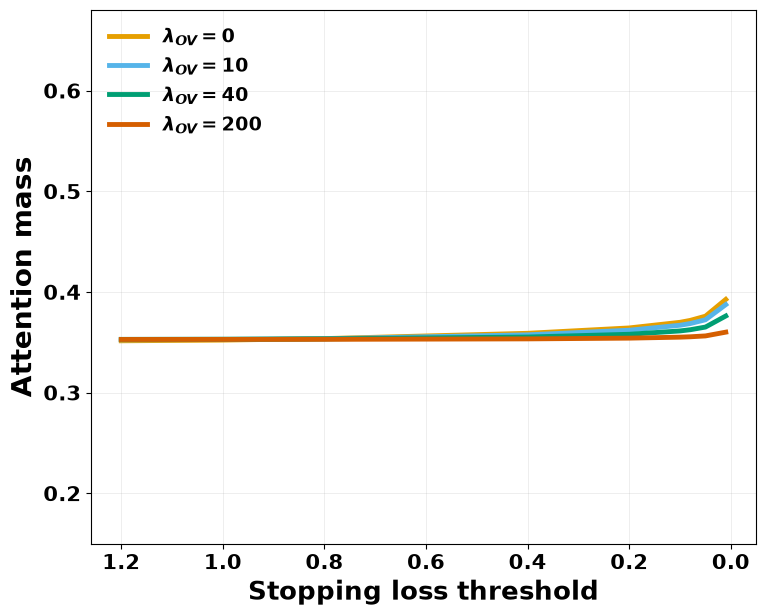

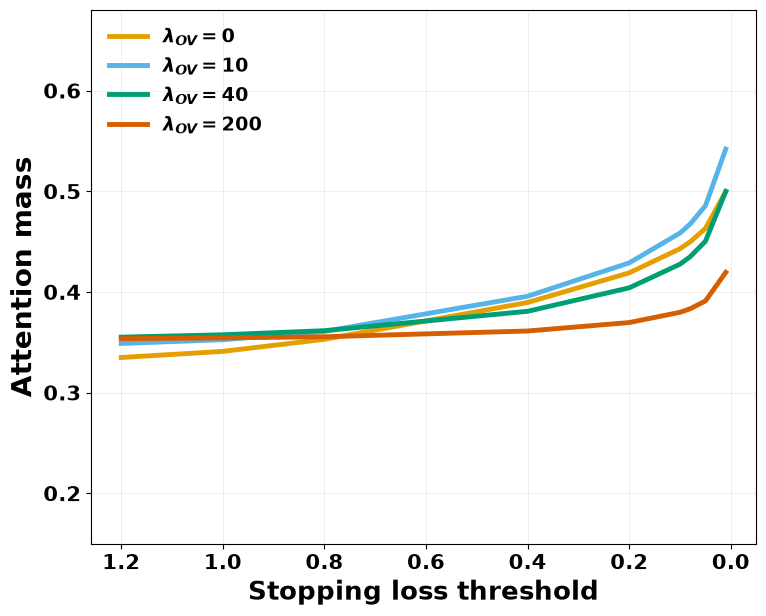

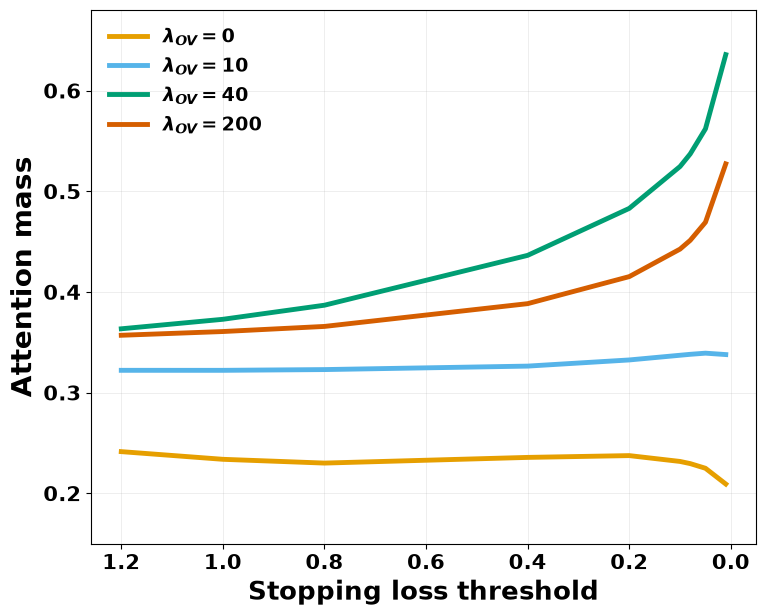

In [97]:
for qk in [0, 40, 200]:
    make_qk_panel(qk, averages, save_path=f'attn_mass_dynamics_qk{qk}.pdf')

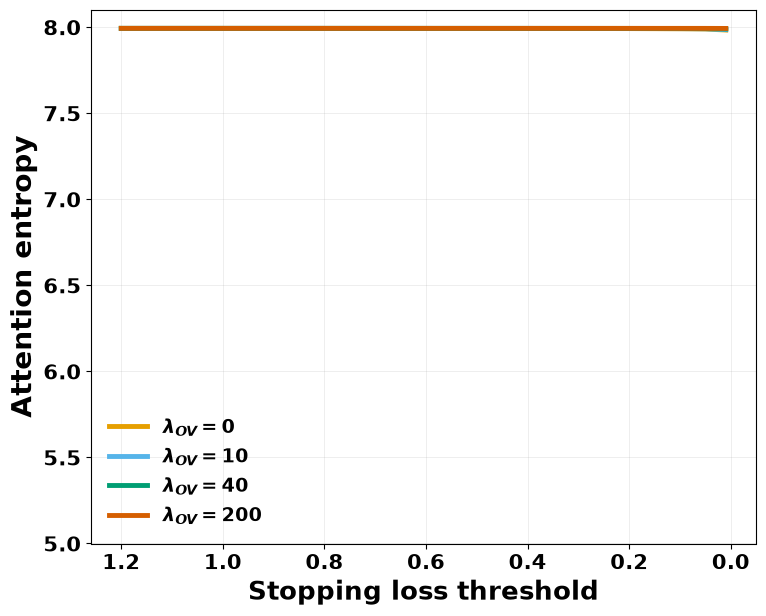

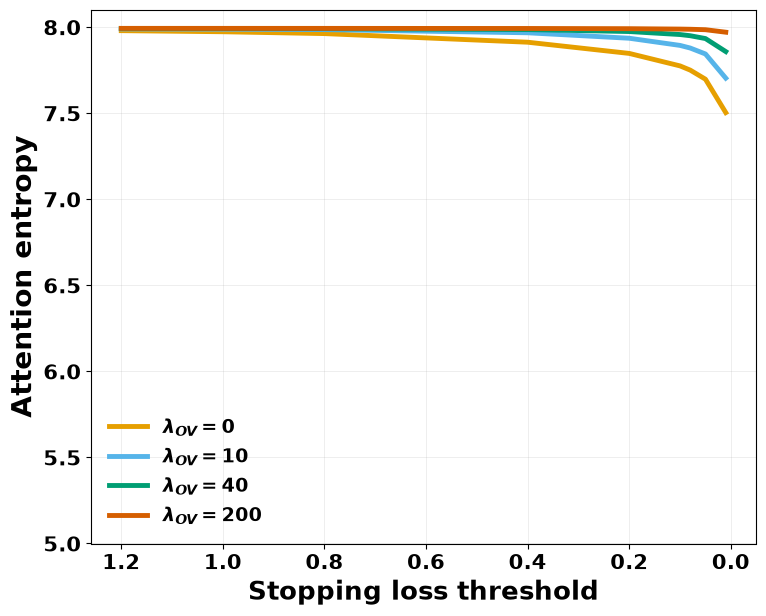

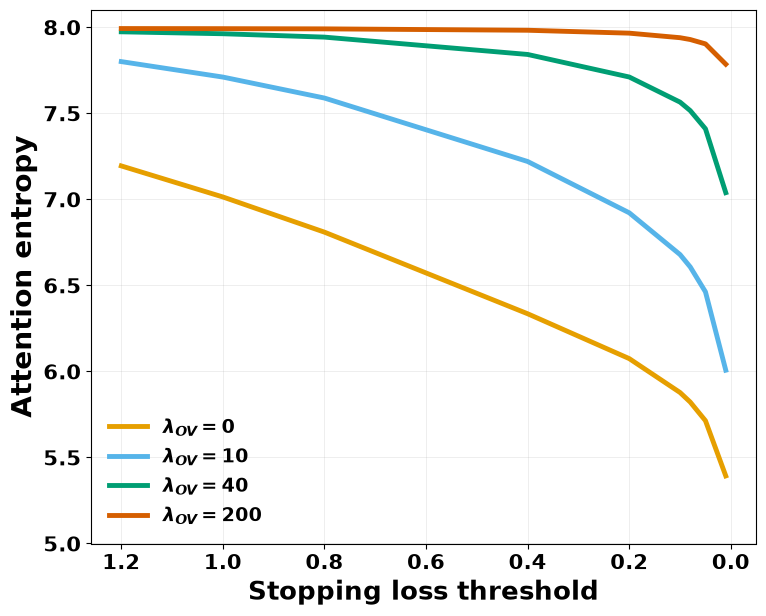

In [98]:
for qk in [0, 40, 200]:
    make_qk_panel_entropy(qk, averages, save_path=f'entropy_dynamics_qk{qk}.pdf')

In [111]:
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 18

OV_VALUES = [0, 10, 40, 200]
# Okabe-Ito colorblind-safe qualitative palette — orange, sky blue, bluish green, vermillion.
OV_COLORS = ['#E69F00', '#56B4E9', '#009E73', '#D55E00']


def build_epoch_averages(trajectory_df, metric_col):
    """Average a trajectory_df metric over the 5 seeds, per (lambda_qk, lambda_ov, epoch)."""
    grouped = trajectory_df.groupby(['lambda_qk', 'lambda_ov', 'epoch'])[metric_col]
    means = grouped.mean().reset_index(name='mean')
    stds = grouped.std(ddof=0).reset_index(name='std')
    return means.merge(stds, on=['lambda_qk', 'lambda_ov', 'epoch'])


def make_qk_panel_epoch(qk, epoch_df, ylabel, ov_values=OV_VALUES, colors=OV_COLORS,
                         ylim=None, show_std_band=True, save_path=None):
    fig, ax = plt.subplots(figsize=(8, 6.5))

    for ov, c in zip(ov_values, colors):
        sub = epoch_df[(epoch_df.lambda_qk == qk) & (epoch_df.lambda_ov == ov)].sort_values('epoch')
        ax.plot(sub.epoch, sub['mean'], label=rf'$\lambda_{{OV}}={ov}$', color=c, linewidth=3.5)
        if show_std_band:
            ax.fill_between(sub.epoch, sub['mean'] - sub['std'], sub['mean'] + sub['std'],
                             color=c, alpha=0.15, linewidth=0)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel('Training Epochs', fontsize=19)
    ax.set_ylabel(ylabel, fontsize=20)
    #ax.set_title(rf'{ylabel} over Training ($\lambda_{{QK}}={qk}$)', fontsize=21)

    ax.tick_params(labelsize=15)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    ax.legend(fontsize=14, frameon=False, loc='upper left')

    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    return fig, ax


# --- usage ---
# NOTE: epoch-axis comparisons put different (lambda_qk, lambda_ov) configs at
# mismatched optimization progress, since each converges at a different rate.
# This is a deliberate tradeoff vs. the loss-threshold-axis figures elsewhere
# in the paper, which compare configs at matched training loss instead.




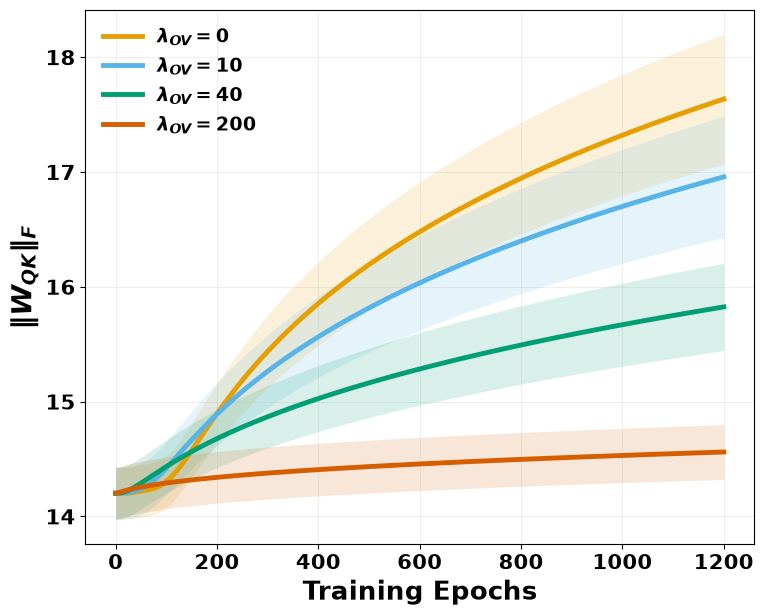

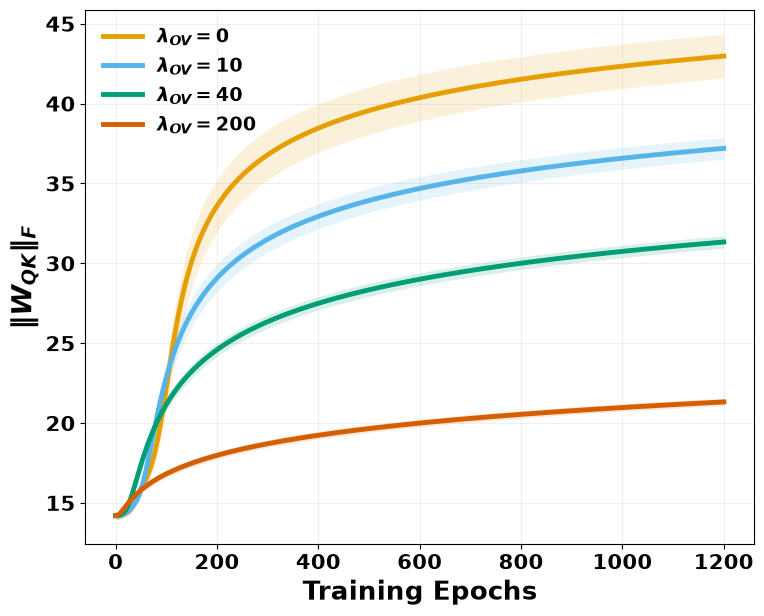

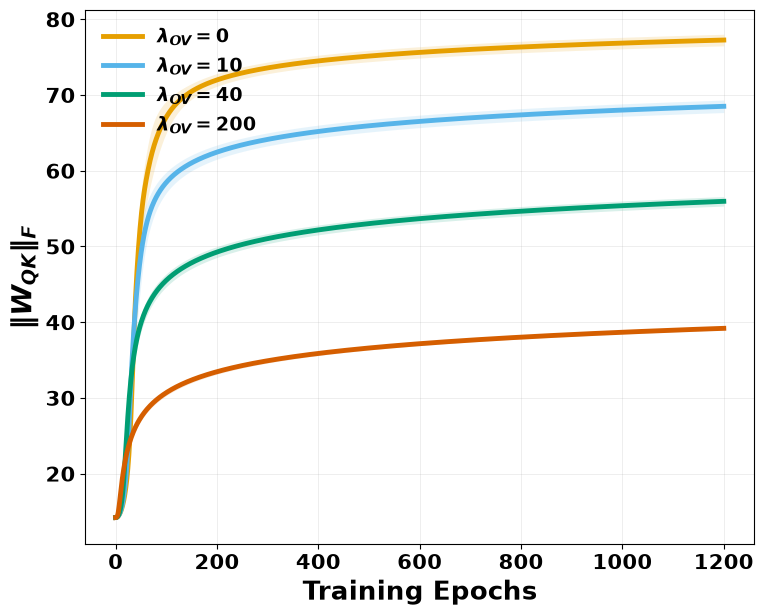

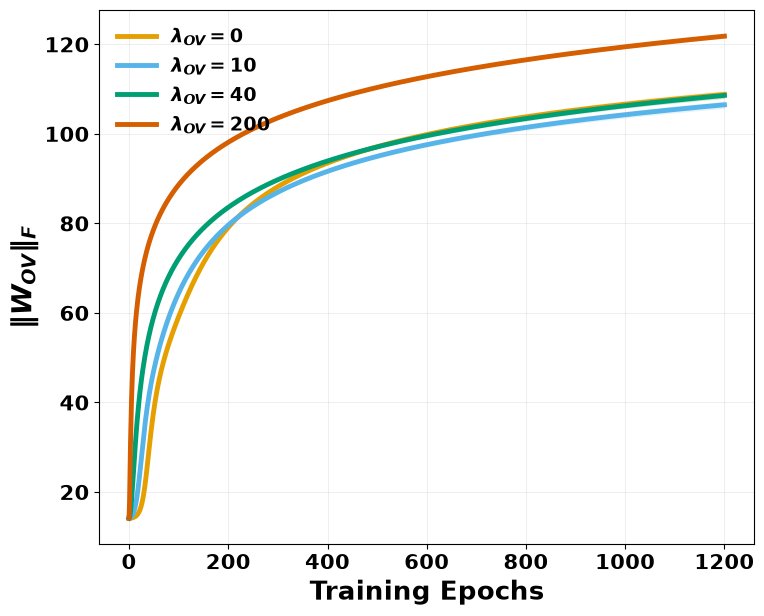

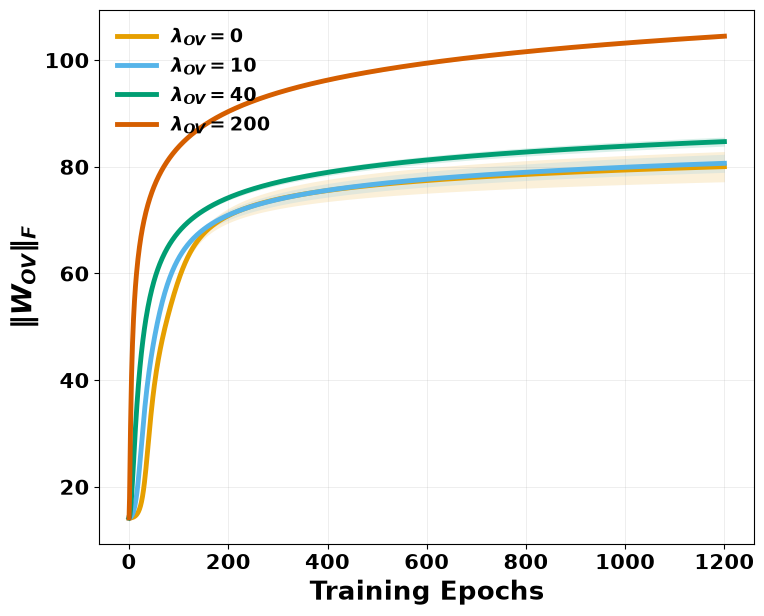

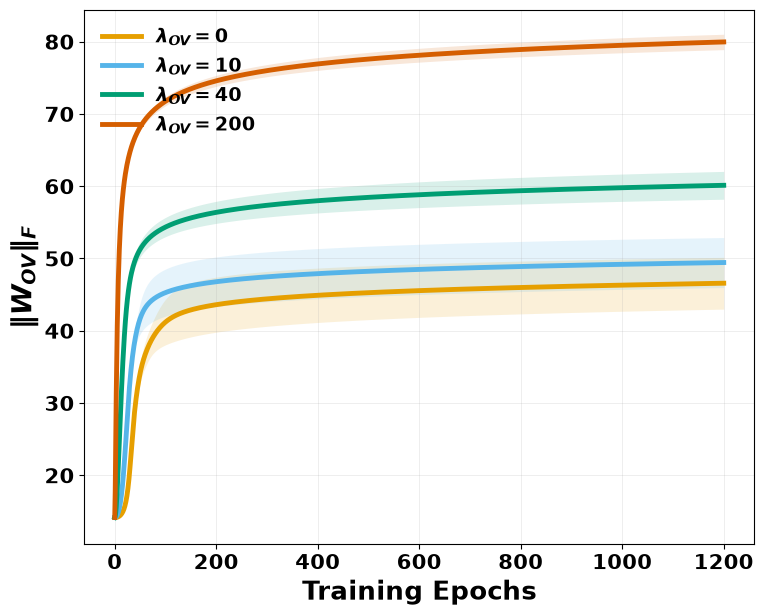

In [113]:
metric_specs = [
    #('distinct_mass_mean', 'Attention Mass', 'attn_mass'),
    ('qk_product_norm', r'$\|W_{QK}\|_F$', 'qk_product_norm'),
    ('ov_product_norm', r'$\|W_{OV}\|_F$', 'ov_product_norm'),
    #('entropy_bits_mean', 'Entropy (bits)', 'entropy'),
]

for metric_col, ylabel, tag in metric_specs:
    epoch_df = build_epoch_averages(trajectory_df, metric_col)
    for qk in [0, 40, 200]:
        make_qk_panel_epoch(qk, epoch_df, ylabel=ylabel,
                             save_path=f'{tag}_epoch_dynamics_qk{qk}.pdf')